# Zero Padding in Transient ISE
As [previously described](circular_convolution.ipynb), zero padding is required in transient ISE (with frequency domain deconvolution) to ensure that the responses and FRFs have the same frequency resolution. Extra zero padding is also commonly used to avoid circular convolution errors. Zero padding the responses is relatively straight forward, since they can be zero padded directly in the time domain prior to the conversion to the frequency domain. However, the process is not quite as straight forward for the FRFs since it is actually an interpolation, which is the Fourier transform dual of zero padding. There are two main options for "zero padding" the FRFs:

- Sinc interpolation, which converts the FRFs to IRFs, zero pads the IRFs, then converts the zero padded IRFs back to FRFs with a finer frequency resolution
- Frequency interpolation, which directly interpolates between the existing frequency lines of the FRFs in the frequency domain

These two methods should be equivalent for causal FRFs, but there are significant differences when the FRFs are contaminated by apparent non-causalities, which will be demonstrated in this notebook. 

## Non-causal Representation of the Example System
First, a non-causal representation of the example system will be developed so the apparent non-causalities can be easily shown. This is done by computing the band limited FRFs and downsampling the responses and truth pulses. In this example, the frequency band will be limited to the 0-500 Hz frequency range, which was [previously shown](sec:band_limited_frfs) to induce apparent non-causalities in the FRFs. 

In [1]:
import sdynpy as sdpy
import numpy as np
from scipy.fft import irfft
from scipy.signal import butter, sosfiltfilt
from forcefinder.core.transient_utilities import frequency_interpolation, sinc_interpolation
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':10,
                     'font.family':'Times New Roman'})

In [2]:
truth_pulse = sdpy.TimeHistoryArray.load(r'system_data/low_freq_truth_pulse_excitation.npz')
truth_response = sdpy.TimeHistoryArray.load(r'system_data/low_freq_truth_response.npz')
nominal_beam_system = sdpy.System.load(r'system_data/nominal_beam_system.npz')

In [3]:
full_Fs = 1/truth_pulse.abscissa_spacing
Fs = 1000 #Hz
T = 1 # seconds
frequency = np.arange(stop=Fs/2+1/T, step=1/T)

Like the other notebooks, the FRFs are being computed from the nominal beam `System` object using the `frequency_response` method. 

In [ ]:
response_coordinate = sdpy.coordinate_array(node=[102,104,106,108], direction=3)
reference_coordinate = sdpy.coordinate_array(string_array=['103Z+', '104Z+'])

undersampled_frfs = nominal_beam_system.frequency_response(frequency, responses=response_coordinate, 
                                         references=reference_coordinate, displacement_derivative=2)

Both the responses and pulses are lowpass filtered with a cutoff frequency of 475 Hz. This filter is a 20th order butterworth filter that is defined with second order sections and is applied with the typical forward-backward zero phase approach. 

In [5]:
sos_filt = butter(20, 475, 'low', output='sos', fs=Fs)

filtered_response = sosfiltfilt(sos_filt, truth_response.ordinate)
filtered_pulse = sosfiltfilt(sos_filt, truth_pulse.ordinate)

After filtering, the responses and pulses are downsampled via a simple indexing operation. 

In [ ]:
undersampled_time = truth_pulse[0].abscissa[0:-1:int(full_Fs/Fs)]

undersampled_response = filtered_response[:,0:-1:int(full_Fs/Fs)]
undersampled_response = sdpy.time_history_array(undersampled_time, undersampled_response, 
                                                truth_response.coordinate)

undersampled_pulse = filtered_pulse[:,0:-1:int(full_Fs/Fs)]
undersampled_pulse = sdpy.time_history_array(undersampled_time, undersampled_pulse, 
                                             truth_pulse.coordinate)

Lastly, the responses are prepared for the upcoming ISE operations by zero padding to mitigate [circular convolution errors](circular_convolution.ipynb), then converting to the frequency domain. 

In [7]:
undersampled_model_order = undersampled_frfs.ifft().num_elements
padded_undersampled_response = undersampled_response.zero_pad(2*undersampled_model_order, 
                                                              left=True, right=True,
                                                              use_next_fast_len=False)
padded_undersampled_response_fft = padded_undersampled_response.fft(norm='backward')
padded_undersampled_response_fft_ord = np.moveaxis(padded_undersampled_response_fft.ordinate,-1,0)[...,np.newaxis]

## Sinc Interpolation
The FRFs are sinc interpolated using the `sinc_interpolation` function from ForceFinder. As expected, sinc interpolation on an FRF with apparent non-causalities simply adds zeros after the ring-up. This zero-padding results in a non-physical IRF, which causes significant errors in the FRF. These errors are shown in the plot below that compares the original FRF to the interpolated FRF. 

In [8]:
frfs_sinc_interpolated = sinc_interpolation(np.moveaxis(undersampled_frfs.ordinate,-1,0), 
                                            padded_undersampled_response.num_elements)
interpolated_freq = np.arange(frfs_sinc_interpolated.shape[0])*Fs/2/frfs_sinc_interpolated.shape[0]

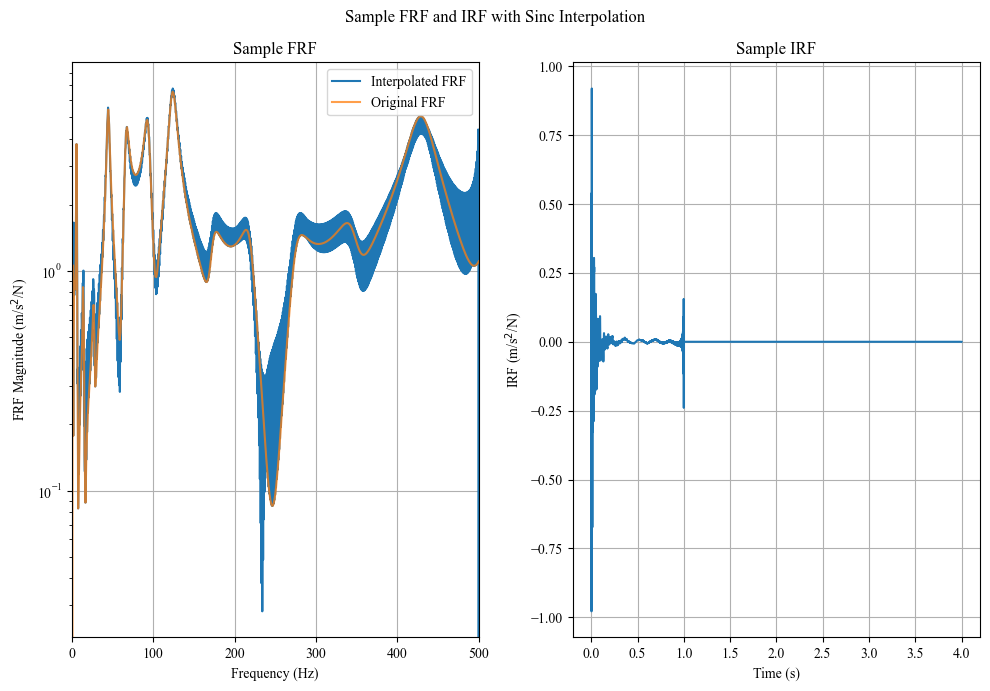

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,7))

ax_ind = 0
ax[ax_ind].semilogy(interpolated_freq, np.abs(frfs_sinc_interpolated[:,0,1]), label='Interpolated FRF')
ax[ax_ind].semilogy(undersampled_frfs[2,1].abscissa, np.abs(undersampled_frfs[0,1].ordinate), 
                    label='Original FRF', alpha=0.75)
ax[ax_ind].set_xlim(left=0, right=500)
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Frequency (Hz)'); ax[ax_ind].set_ylabel('FRF Magnitude (m/s$^2$/N)') 
ax[ax_ind].set_title('Sample FRF'); ax[ax_ind].legend()

ax_ind = 1
ax[ax_ind].plot(padded_undersampled_response[0].abscissa+1, irfft(frfs_sinc_interpolated[:,0,1]))
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Time (s)'); ax[ax_ind].set_ylabel('IRF (m/s$^2$/N)') 
ax[ax_ind].set_title('Sample IRF');

fig.suptitle('Sample FRF and IRF with Sinc Interpolation')
fig.tight_layout()

The source estimation with the sinc interpolated FRFs results in significant errors, as shown in the plot below that compares the estimated pulse to the truth pulse.

In [10]:
estimated_pulse_fft_sinc_interpolation = np.linalg.pinv(frfs_sinc_interpolated)@padded_undersampled_response_fft_ord
estimated_pulse_sinc_interpolation = irfft(estimated_pulse_fft_sinc_interpolation, 
                                           n=padded_undersampled_response.num_elements, 
                                           axis=0, norm='backward')

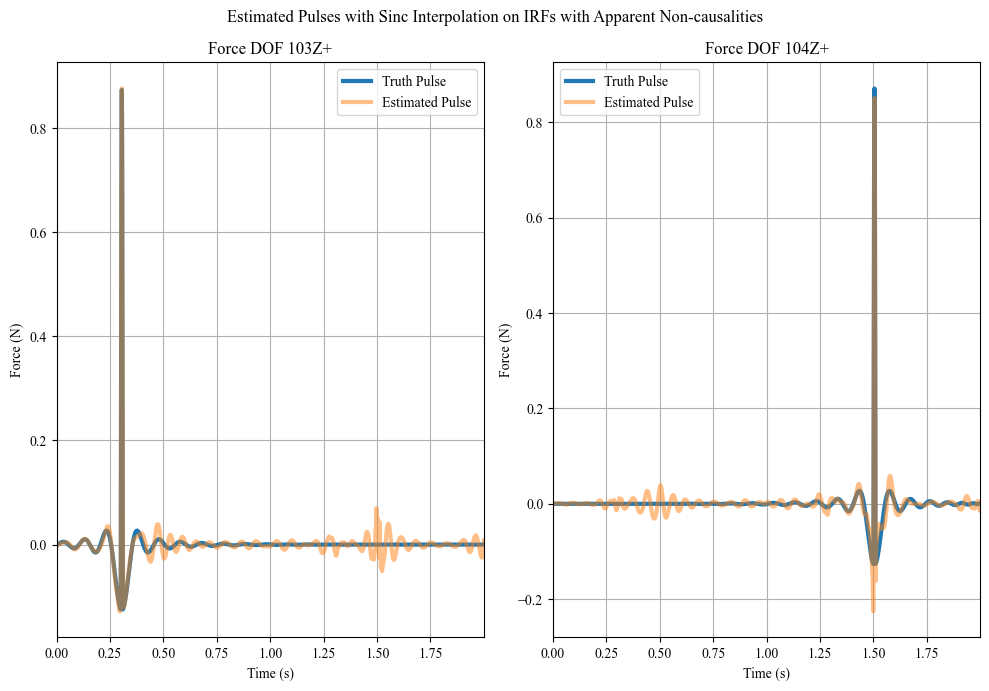

In [11]:
fig, ax = plt.subplots(1,2, figsize=(10,7))

ax_ind = 0
ax[ax_ind].plot(undersampled_pulse[ax_ind].abscissa, undersampled_pulse[ax_ind].ordinate, 
                label='Truth Pulse', linewidth=3)
ax[ax_ind].plot(padded_undersampled_response[0].abscissa, estimated_pulse_sinc_interpolation[:,ax_ind,:], 
                label='Estimated Pulse', linewidth=3, alpha=0.5)
ax[ax_ind].set_xlim(left=undersampled_pulse.abscissa.min(), right=undersampled_pulse.abscissa.max())
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Time (s)'); ax[ax_ind].set_ylabel('Force (N)') 
ax[ax_ind].set_title('Force DOF {:}'.format(undersampled_pulse[ax_ind].response_coordinate.string_array()));
ax[ax_ind].legend()

ax_ind = 1
ax[ax_ind].plot(undersampled_pulse[ax_ind].abscissa, undersampled_pulse[ax_ind].ordinate, 
                label='Truth Pulse', linewidth=3)
ax[ax_ind].plot(padded_undersampled_response[0].abscissa, estimated_pulse_sinc_interpolation[:,ax_ind,:], 
                label='Estimated Pulse', linewidth=3, alpha=0.5)
ax[ax_ind].set_xlim(left=undersampled_pulse.abscissa.min(), right=undersampled_pulse.abscissa.max())
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Time (s)'); ax[ax_ind].set_ylabel('Force (N)') 
ax[ax_ind].set_title('Force DOF {:}'.format(undersampled_pulse[ax_ind].response_coordinate.string_array()));
ax[ax_ind].legend()

fig.suptitle('Estimated Pulses with Sinc Interpolation on IRFs with Apparent Non-causalities')
fig.tight_layout()

## Frequency Interpolation
The frequency interpolation is performed with the `frequency_interpolation` function from ForceFinder, which uses cubic interpolation on the complex FRF. Unlike the sinc interpolation, the frequency interpolation keeps the ring-up at the end of the IRF, which means that the shape of the FRF magnitude is relatively unaffected by the interpolation, as shown in the plot below. 

In [12]:
frfs_cubic_interpolated = frequency_interpolation(undersampled_frfs[0,0].abscissa, 
                                                  np.moveaxis(undersampled_frfs.ordinate,-1,0),
                                                  padded_undersampled_response.num_elements, 
                                                  padded_undersampled_response.abscissa_spacing)

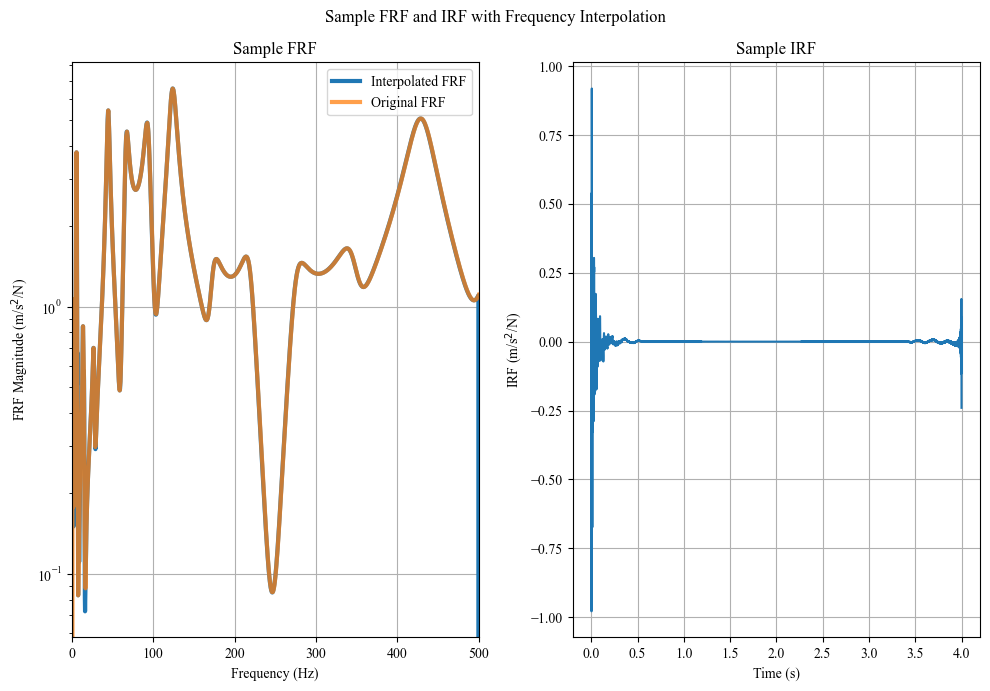

In [14]:
fig, ax = plt.subplots(1,2, figsize=(10,7))

ax_ind = 0
ax[ax_ind].semilogy(interpolated_freq, np.abs(frfs_cubic_interpolated[:,0,1]), linewidth=3, 
                    label='Interpolated FRF')
ax[ax_ind].semilogy(undersampled_frfs[2,1].abscissa, np.abs(undersampled_frfs[0,1].ordinate), 
                    linewidth=3, label='Original FRF', alpha=0.75)
ax[ax_ind].set_xlim(left=0, right=500)
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Frequency (Hz)'); ax[ax_ind].set_ylabel('FRF Magnitude (m/s$^2$/N)') 
ax[ax_ind].set_title('Sample FRF'); ax[ax_ind].legend()

ax_ind = 1
ax[ax_ind].plot(padded_undersampled_response[0].abscissa+1, irfft(frfs_cubic_interpolated[:,0,1]))
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Time (s)'); ax[ax_ind].set_ylabel('IRF (m/s$^2$/N)') 
ax[ax_ind].set_title('Sample IRF');

fig.suptitle('Sample FRF and IRF with Frequency Interpolation')
fig.tight_layout()

The estimated sources with frequency interpolated FRFs have some minor errors, which are much less significant than the errors in the estimated sources from the sinc interpolated FRFs. 

In [15]:
estimated_pulse_fft_cubic_interpolation = np.linalg.pinv(frfs_cubic_interpolated)@padded_undersampled_response_fft_ord
estimated_pulse_cubic_interpolation = irfft(estimated_pulse_fft_cubic_interpolation, 
                                            n=padded_undersampled_response.num_elements, 
                                            axis=0, norm='backward')

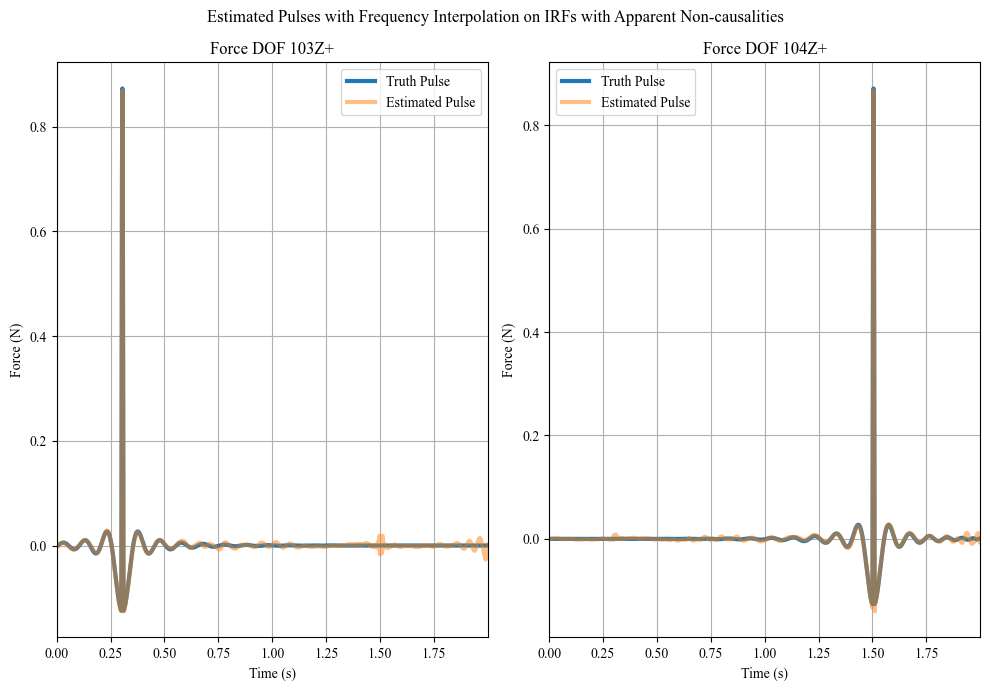

In [16]:
fig, ax = plt.subplots(1,2, figsize=(10,7))

ax_ind = 0
ax[ax_ind].plot(undersampled_pulse[ax_ind].abscissa, undersampled_pulse[ax_ind].ordinate, 
                label='Truth Pulse', linewidth=3)
ax[ax_ind].plot(padded_undersampled_response[0].abscissa, estimated_pulse_cubic_interpolation[:,ax_ind,:], 
                label='Estimated Pulse', linewidth=3, alpha=0.5)
ax[ax_ind].set_xlim(left=undersampled_pulse.abscissa.min(), right=undersampled_pulse.abscissa.max())
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Time (s)'); ax[ax_ind].set_ylabel('Force (N)') 
ax[ax_ind].set_title('Force DOF {:}'.format(undersampled_pulse[ax_ind].response_coordinate.string_array()));
ax[ax_ind].legend()

ax_ind = 1
ax[ax_ind].plot(undersampled_pulse[ax_ind].abscissa, undersampled_pulse[ax_ind].ordinate, 
                label='Truth Pulse', linewidth=3)
ax[ax_ind].plot(padded_undersampled_response[0].abscissa, estimated_pulse_cubic_interpolation[:,ax_ind,:], 
                label='Estimated Pulse', linewidth=3, alpha=0.5)
ax[ax_ind].set_xlim(left=undersampled_pulse.abscissa.min(), right=undersampled_pulse.abscissa.max())
ax[ax_ind].grid(); ax[ax_ind].set_xlabel('Time (s)'); ax[ax_ind].set_ylabel('Force (N)') 
ax[ax_ind].set_title('Force DOF {:}'.format(undersampled_pulse[ax_ind].response_coordinate.string_array()));
ax[ax_ind].legend()

fig.suptitle('Estimated Pulses with Frequency Interpolation on IRFs with Apparent Non-causalities')
fig.tight_layout()

## Zero Padding In Response Predictions
While not the focus of this study, it is important to note that zero padding is commonly used in the convolution algorithms that compute responses from IRFs and time domain forces. The effects of zero padding in the response prediction will not be explored here, but anecdotal experience indicates that they will be similar to the effects that were seen on the ISE problem. 